# Critical bubble by the shooting method

Units: T0 = 1, and phi, r and T are measured in these units.

In [77]:
import numpy as np
import math
import os
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

## 1. The potential

$V(\phi,T) = D(T^2-T_0^2)\phi^2 - E\,T\,\phi^3 + \tfrac{\lambda}{4}\phi^4$

In [4]:
lam, D, E, T0 = 0.1, 0.1, 0.05, 1.0

def V(phi, T):
    return (D * (T ** 2 - T0 ** 2) * phi ** 2 - E * T * phi ** 3 + (lam / 4) * phi ** 4)
    
def dV(phi, T):
    return (D * (T ** 2 - T0 ** 2) * phi * 2 - 3 * E * T * phi ** 2 + lam * phi ** 3)

### Check

In [5]:
h = 1e-6
phi, T = 0.8, 1.1
print(dV(phi, T), (V(phi + h, T) - V(phi - h, T)) / (2 * h))

-0.020799999999999992 -0.0208000000053582


In [31]:
def disc2(T):
    a, b, c = lam, (-3 * E * T), 2 * D * (T ** 2 - T0 ** 2)
    return b**2 - 4 * a * c
    
def extrema(T): # solve lam*phi^2 - 3*E*T*phi + 2*D*(T^2-T0^2) = 0 with the quadratic formula.
    a, b, c = lam, (-3 * E * T), 2 * D * (T ** 2 - T0 ** 2) 
    disc = b**2 - 4 * a * c
    if disc >= 0:
        phi_m, phi_p = ((-b - math.sqrt(disc)) / (2 * a)), ((-b + math.sqrt(disc)) / (2 * a))
        return phi_m, phi_p
    else:
        return None

# Analytic critical values from your derivation
Tc = math.sqrt(T0**2 / (1 - (E ** 2 / (lam * D))))
phic = 2 * E * Tc / lam
sigma = math.sqrt(lam/2) * phic**3 / 6
print(Tc, phic, sigma)

1.1547005383792515 1.1547005383792515 0.057377531054924685


### Check

In [46]:
T = 1.12
pm, pp = extrema(T)
T1 = brentq(disc2,1.0,1.5)
print(dV(pm, T), dV(pp, T), T1, (Tc+T0)/2)

8.673617379884035e-19 -2.7755575615628914e-17 1.179535649239177 1.0773502691896257


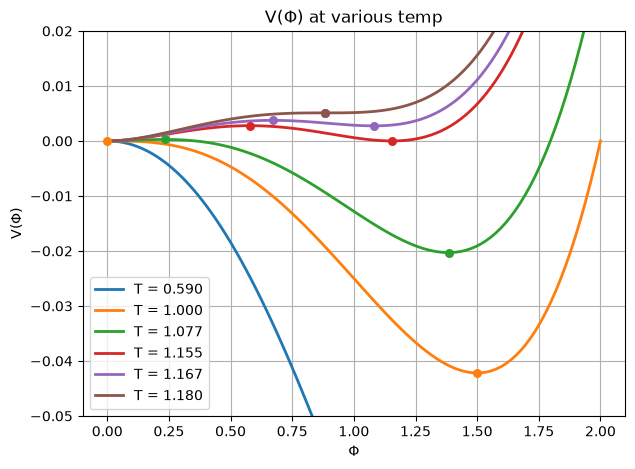

In [79]:
temp = [T1/2, T0, (Tc+T0)/2, Tc, ((T1 + Tc) / 2), T1]
x = np.linspace(0.0, 2, 100)
plt.figure(figsize = (7,5))
for t in temp: 
    (line,) = plt.plot(x, V(x, t), linewidth = 2, label = f"T = {t:.3f}")

    for p in extrema(t):
        if p >=0:
            plt.scatter(p, V(p, t), s = 30, zorder = 5, color = line.get_color())

plt.ylim(-0.05, 0.02)
# plt.ylim(-0.01,0.01) # use this one to see the barrier near T_c clearly
plt.title("V(Φ) at various temp")
plt.xlabel("Φ")
plt.ylabel("V(Φ)")
plt.grid(True)
plt.legend()
plt.savefig("figures/V_at_various_Temp.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. The integrator

Equation: $\phi'' + \tfrac{2}{r}\phi' = V'(\phi)$. Writing it as a first-order system $\Phi=(\phi,\phi')$:
$\Phi_0' = \Phi_1$ and $\Phi_1' = V'(\Phi_0) - \tfrac{2}{r}\Phi_1$.



The false vacuum is at $\phi = 0$. Two events stop the integration:
- **overshoot**: $\phi$ crosses 0 going downward (event function `Phi[0]`, direction -1),
- **undershoot**: $\phi'$ becomes positive (event function `Phi[1]`, direction +1).

In [65]:
def shoot(phi0, T, rmax = 200.0, r0 = 1e-4, rtol = 1e-10, atol = 1e-12):
    # Integrate from r0 with initial value phi0. Return (flag, sol): flag = +1 overshoot, -1 undershoot, 0 neither before rmax.
    c = dV(phi0, T)
    Phi0  = [phi0 + c * r0 ** 2 / 6, c * r0 / 3]

    def rhs(r, Phi):
        # return [Phi[0]', Phi[1]'] as above
        return [Phi[1], (dV(Phi[0], T) - 2 * Phi[1] / r)]

    def over(r, Phi):  return Phi[0]
    over.terminal, over.direction = True, -1
    def under(r, Phi): return Phi[1]
    under.terminal, under.direction = True, 1

    sol = solve_ivp(rhs, [r0, rmax], Phi0, events = [over, under], rtol = rtol, atol = atol, dense_output = True)
    if sol.t_events[0].size: return +1, sol
    if sol.t_events[1].size: return -1, sol
    return 0, sol

### Check

In [73]:
for phi0 in np.linspace(1.2, pp, 11)[:-1]:
    print(f"{phi0:.4f}", shoot(phi0, 1.12)[0])

1.2000 -1
1.2084 -1
1.2167 -1
1.2251 -1
1.2334 1
1.2418 1
1.2502 1
1.2585 1
1.2669 1
1.2753 1


## 3. Bisection on phi0

Overshoot means phi0 is too close to the broken minimum, so lower `hi`. Undershoot means raise `lo`.

In [74]:
def bounce(T, tol=1e-12):
    pm, pp = extrema(T)
    lo = pm + 1e-9*(pp - pm)
    hi = pp - 1e-9*(pp - pm)
    assert shoot(lo, T)[0] < 0 and shoot(hi, T)[0] > 0, "bracket failed"
    for _ in range(200):
        mid = (lo+hi)/2
        flag, _ = shoot(mid, T)
        if flag > 0:
            hi = mid
        else:
            lo = mid
        if hi - lo > tol * pp:
            break
    phi0 = (lo + hi) / 2
    flag, sol = shoot(phi0, T)
    return phi0, sol

In [83]:
phi0, sol = bounce(1.12)
print(phi0, sol.t[-1])

1.061810729684567 25.225728225375633


Text(0, 0.5, 'φ')

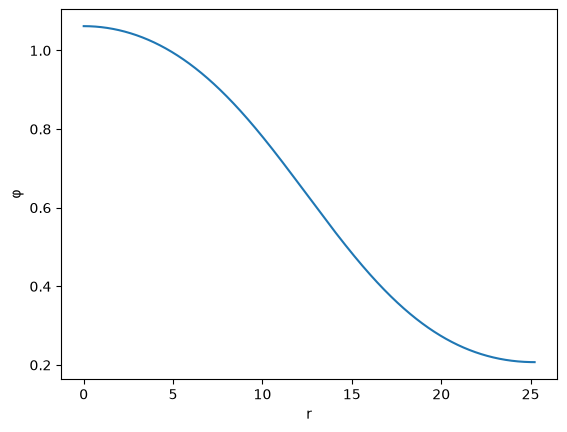

In [82]:
r = np.linspace(1e-4, sol.t[-1], 2000)
plt.plot(r, sol.sol(r)[0]); plt.xlabel("r"); plt.ylabel("φ")